## Testing GitHub Palmistry Model

The GitHub palmistry model is tested on the same palm images used for the Roboflow API evaluation. The objective is to compare the visual accuracy of heart-line, head-line, and life-line detection.

In [42]:
!pip uninstall -y tensorflow tensorflow-cpu tensorflow-io-gcs-filesystem
!pip uninstall -y mediapipe protobuf

!pip install -q protobuf==4.25.3
!pip install -q mediapipe==0.10.14 pillow-heif

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
Found existing installation: protobuf 4.25.3
Uninstalling protobuf-4.25.3:
  Successfully uninstalled protobuf-4.25.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.3 which is incompatible.
google-cloud-vision 3.15.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-videointelligence 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
a2a-sdk 0.3.26 requires protobuf>=5.29.5, but you have

In [43]:
import mediapipe as mp
import google.protobuf

print("MediaPipe version:", mp.__version__)
print("Protobuf version:", google.protobuf.__version__)
print("MediaPipe solutions available:", hasattr(mp, "solutions"))

MediaPipe version: 0.10.14
Protobuf version: 4.25.3
MediaPipe solutions available: True


In [44]:
import os
import glob
import json
import random
import shutil
import subprocess

import mediapipe as mp
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pprint import pprint
from kaggle_secrets import UserSecretsClient
from google import genai

In [45]:
!git clone https://github.com/yeonsumia/palmistry.git

fatal: destination path 'palmistry' already exists and is not an empty directory.


In [46]:
image_files = (
    glob.glob("/kaggle/input/**/*.jpg", recursive=True) +
    glob.glob("/kaggle/input/**/*.jpeg", recursive=True) +
    glob.glob("/kaggle/input/**/*.png", recursive=True)
)

print("Total images:", len(image_files))

Total images: 11154


In [47]:
import os
import shutil

source_checkpoint = (
    "/kaggle/working/palmistry/code/checkpoint/"
    "checkpoint_aug_epoch70.pth"
)

destination_folder = (
    "/kaggle/working/palmistry/checkpoint"
)

destination_checkpoint = os.path.join(
    destination_folder,
    "checkpoint_aug_epoch70.pth"
)

os.makedirs(destination_folder, exist_ok=True)

shutil.copy(
    source_checkpoint,
    destination_checkpoint
)

print("Checkpoint copied to:")
print(destination_checkpoint)

print(
    "Checkpoint exists:",
    os.path.exists(destination_checkpoint)
)

Checkpoint copied to:
/kaggle/working/palmistry/checkpoint/checkpoint_aug_epoch70.pth
Checkpoint exists: True


In [48]:
classification_path = "/kaggle/working/palmistry/code/classification.py"

with open(classification_path, "r") as file:
    content = file.read()

old_code = (
    "skel_img = cv2.cvtColor("
    "skeletonize(palmline_img), "
    "cv2.COLOR_BGR2GRAY)"
)

new_code = """
skel_bool = skeletonize(palmline_img)
skel_uint8 = (skel_bool.astype("uint8") * 255)

if skel_uint8.ndim == 3:
    skel_img = cv2.cvtColor(
        skel_uint8,
        cv2.COLOR_BGR2GRAY
    )
else:
    skel_img = skel_uint8
"""

if old_code in content:
    content = content.replace(old_code, new_code)

    with open(classification_path, "w") as file:
        file.write(content)

    print("Correct skeleton fix applied.")
else:
    print("Exact old line not found.")

Exact old line not found.


In [49]:
with open(classification_path, "r") as file:
    updated_content = file.read()

print(
    "Old problematic code still exists:",
    "cv2.cvtColor(skeletonize(palmline_img)" in updated_content
)

Old problematic code still exists: False


In [50]:
from pathlib import Path

file_path = Path(
    "/kaggle/working/palmistry/code/classification.py"
)

text = file_path.read_text()

old_code = """
    skel_img = cv2.cvtColor(skeletonize(palmline_img), cv2.COLOR_BGR2GRAY)
"""

new_code = """
    skel_bool = skeletonize(palmline_img)
    skel_uint8 = (skel_bool.astype("uint8") * 255)

    if skel_uint8.ndim == 3:
        skel_img = cv2.cvtColor(
            skel_uint8,
            cv2.COLOR_BGR2GRAY
        )
    else:
        skel_img = skel_uint8
"""

if old_code in text:
    text = text.replace(old_code, new_code)
    file_path.write_text(text)
    print("Skeleton fix applied successfully.")
else:
    print("Old line was not found. The file may already be modified.")

Old line was not found. The file may already be modified.


In [51]:
text = file_path.read_text()

print("Old code still present:",
      "cv2.cvtColor(skeletonize(palmline_img)" in text)

print("New code present:",
      "skel_uint8 = (skel_bool.astype" in text)

Old code still present: False
New code present: True


In [52]:
!python -m py_compile /kaggle/working/palmistry/code/classification.py

In [53]:
process = subprocess.run(
    [
        "python",
        "/kaggle/working/palmistry/code/read_palm.py",
        "--input",
        test_filename
    ],
    cwd="/kaggle/working/palmistry",
    capture_output=True,
    text=True
)

print("Return code:", process.returncode)
print("\nOutput:")
print(process.stdout)
print("\nError:")
print(process.stderr)

Return code: 0

Output:


Error:
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785251017.166140     363 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785251017.194164     360 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
W0000 00:00:1785251018.336901     366 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785251018.353683     367 inference_fee

In [54]:
import os

result_folder = "/kaggle/working/palmistry/results"

print("Result folder exists:", os.path.exists(result_folder))

if os.path.exists(result_folder):
    print("Files:")
    for file in os.listdir(result_folder):
        print(file)

Result folder exists: True
Files:
warped_palm_clean_mini.jpg
warped_palm.jpg
warped_palm_clean.jpg
warped_palm_mini.jpg
palm_lines.png
warped_1-2.jpg
out_1-2.jpg
result.jpg
palm_without_background.jpg
out_1-1.jpg
out_1-3.jpg


Total images found: 11154


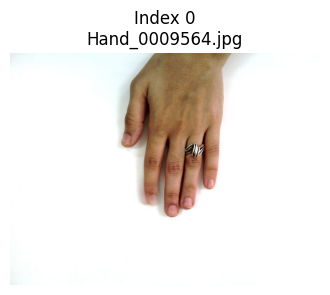

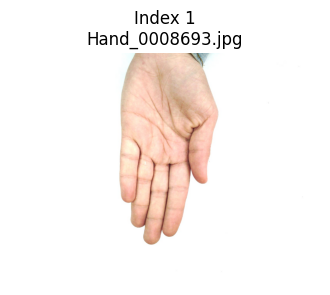

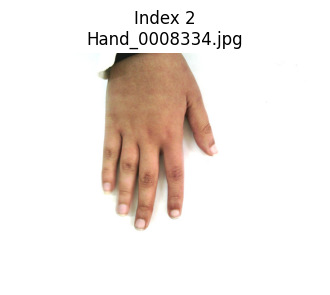

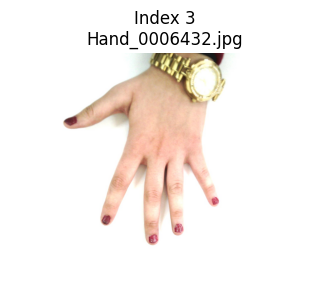

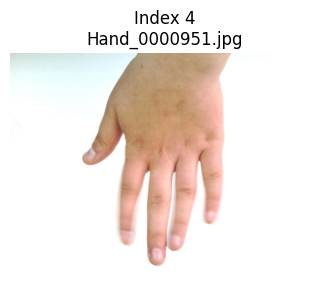

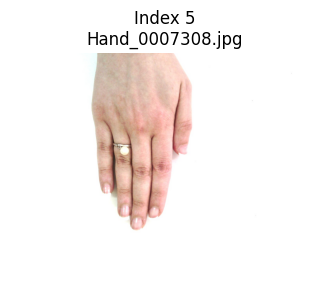

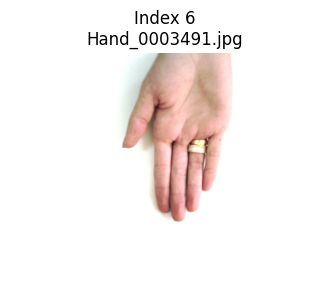

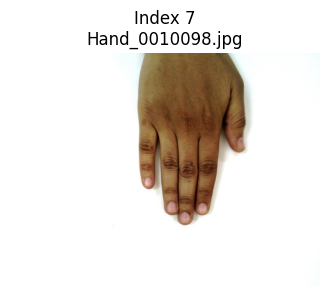

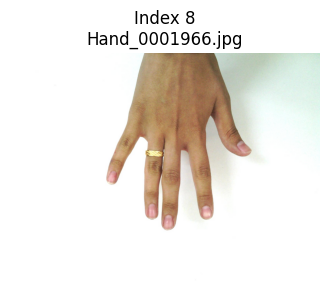

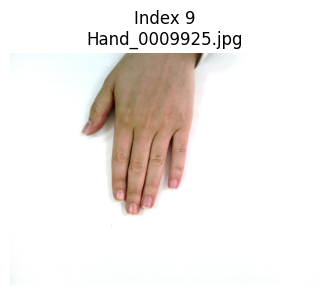

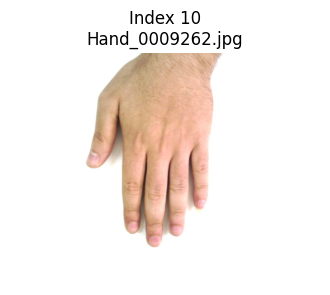

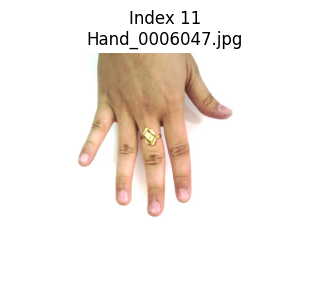

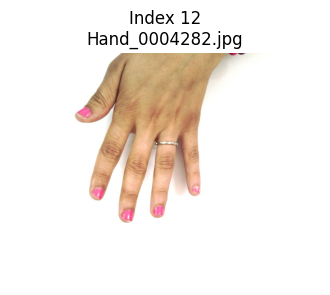

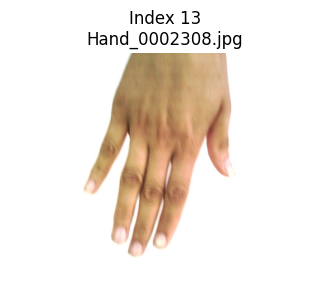

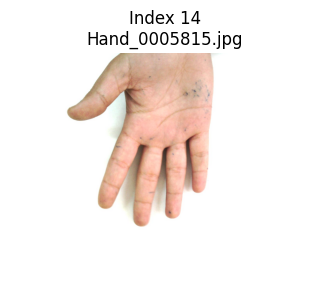

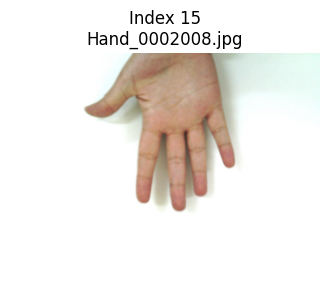

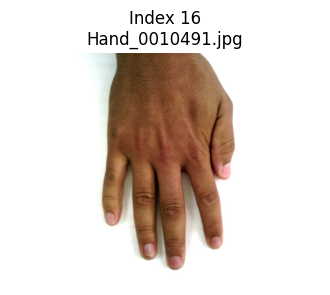

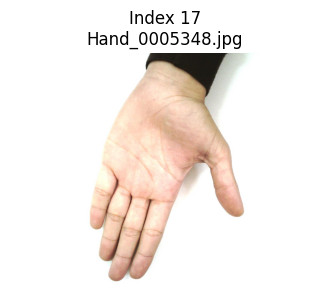

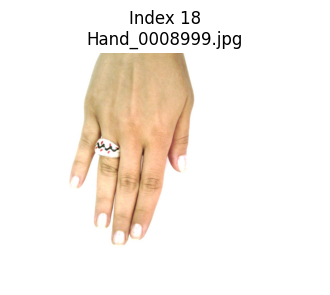

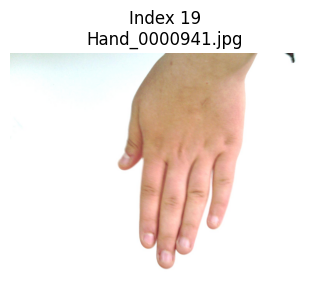

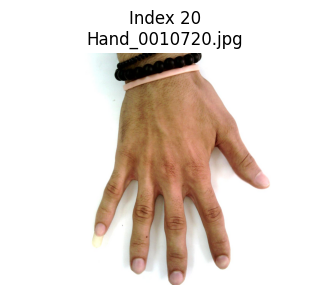

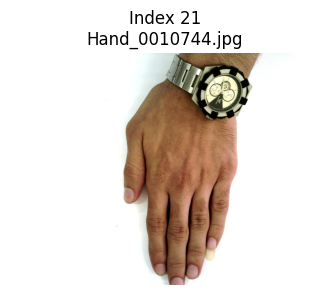

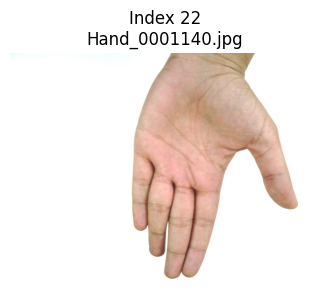

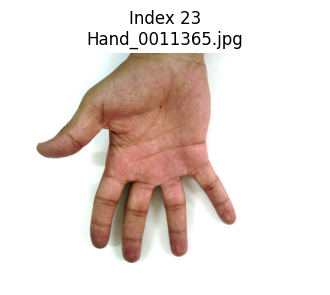

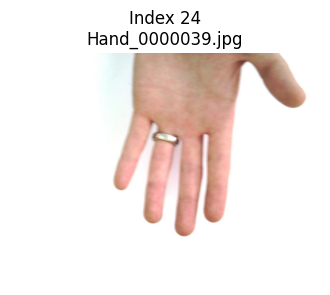

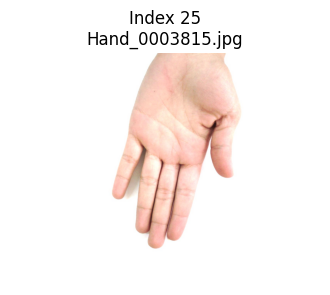

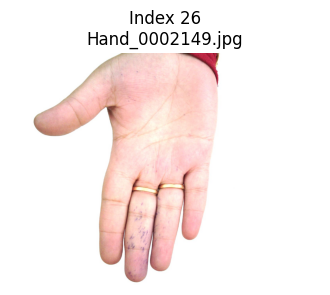

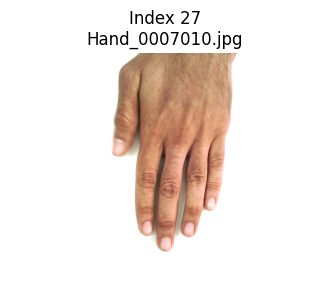

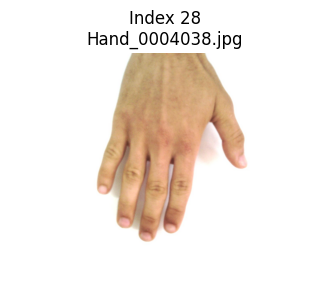

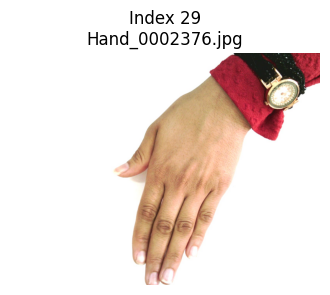

In [55]:
import glob
import matplotlib.pyplot as plt
from PIL import Image
import os

image_files = (
    glob.glob("/kaggle/input/**/*.jpg", recursive=True) +
    glob.glob("/kaggle/input/**/*.jpeg", recursive=True) +
    glob.glob("/kaggle/input/**/*.png", recursive=True)
)

print("Total images found:", len(image_files))

for index, image_path in enumerate(image_files[:30]):
    image = Image.open(image_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Index {index}\n{os.path.basename(image_path)}")
    plt.axis("off")
    plt.show()

In [56]:
selected_index = 14

source_image = image_files[selected_index]

print("Selected image:")
print(source_image)

Selected image:
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0005815.jpg


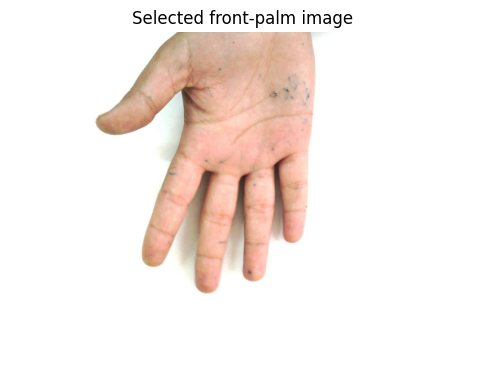

In [57]:
image = Image.open(source_image)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Selected front-palm image")
plt.axis("off")
plt.show()

In [58]:
import shutil
import os

repo_path = "/kaggle/working/palmistry"
input_folder = os.path.join(repo_path, "input")

os.makedirs(input_folder, exist_ok=True)

test_filename = "new_front_palm.jpg"

destination = os.path.join(
    input_folder,
    test_filename
)

shutil.copy(source_image, destination)

print("New image copied to:")
print(destination)

New image copied to:
/kaggle/working/palmistry/input/new_front_palm.jpg


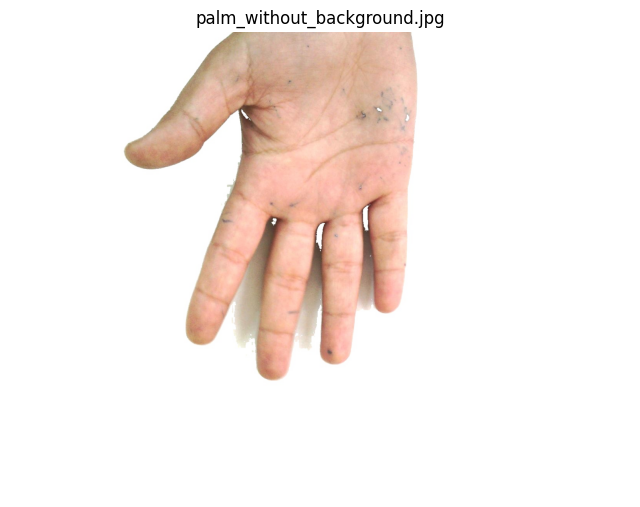

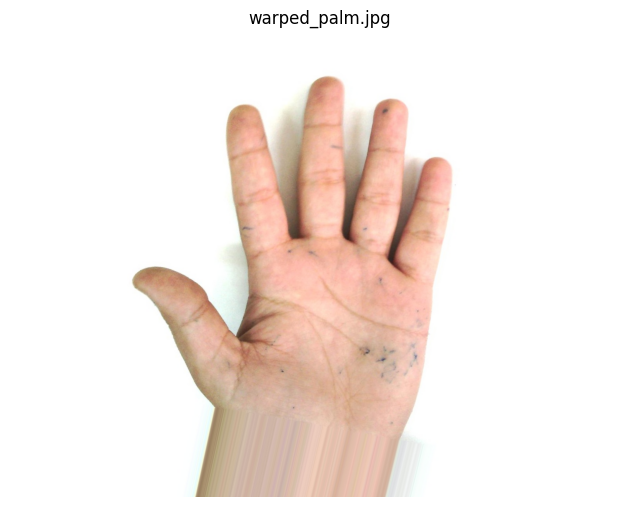

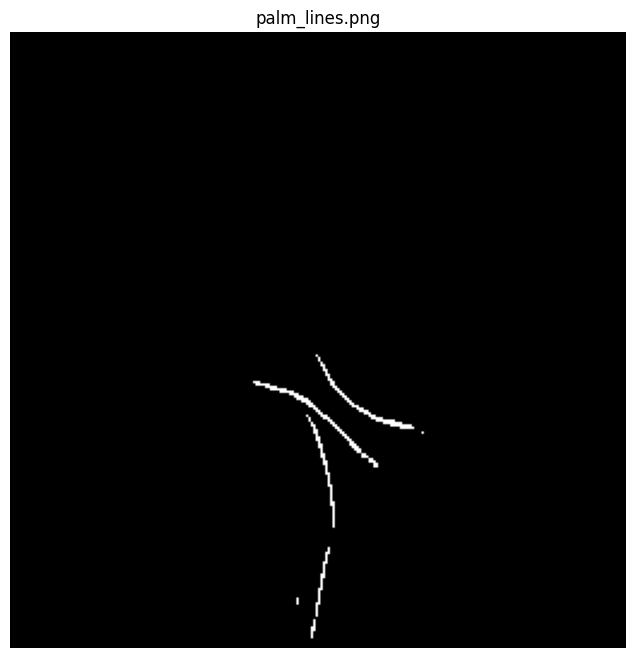

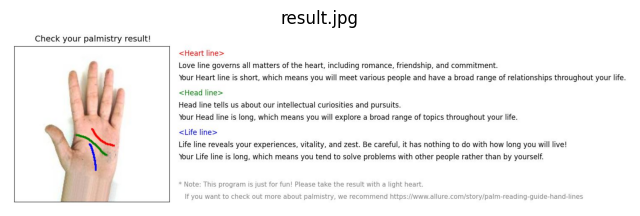

In [59]:
result_folder = "/kaggle/working/palmistry/results"

important_files = [
    "palm_without_background.jpg",
    "warped_palm.jpg",
    "palm_lines.png",
    "result.jpg"
]

for filename in important_files:
    path = os.path.join(result_folder, filename)

    if os.path.exists(path):
        image = Image.open(path)

        plt.figure(figsize=(8, 8))
        plt.imshow(image)
        plt.title(filename)
        plt.axis("off")
        plt.show()

In [60]:
palm_result = {
    "model": "GitHub Palmistry Model",
    "heart_line": {
        "status": "detected",
        "classification": "short"
    },
    "head_line": {
        "status": "detected",
        "classification": "long"
    },
    "life_line": {
        "status": "detected",
        "classification": "long"
    }
}

print(palm_result)

{'model': 'GitHub Palmistry Model', 'heart_line': {'status': 'detected', 'classification': 'short'}, 'head_line': {'status': 'detected', 'classification': 'long'}, 'life_line': {'status': 'detected', 'classification': 'long'}}


In [61]:
def create_palm_prompt(palm_result):
    prompt = f"""
You are a conversational palmistry assistant.

Use only the following model output:

Heart line: {palm_result['heart_line']['classification']}
Head line: {palm_result['head_line']['classification']}
Life line: {palm_result['life_line']['classification']}

Generate a natural conversational interpretation.

Requirements:
- Explain each detected line separately.
- Combine the three lines into one overall reflection.
- Do not make guaranteed predictions.
- Do not make medical claims.
- Present the reading as symbolic guidance and entertainment.
- End with one reflective question.
"""

    return prompt

palm_prompt = create_palm_prompt(palm_result)

print(palm_prompt)


You are a conversational palmistry assistant.

Use only the following model output:

Heart line: short
Head line: long
Life line: long

Generate a natural conversational interpretation.

Requirements:
- Explain each detected line separately.
- Combine the three lines into one overall reflection.
- Do not make guaranteed predictions.
- Do not make medical claims.
- Present the reading as symbolic guidance and entertainment.
- End with one reflective question.



## GitHub Palm Analysis Result

The GitHub palmistry model successfully processed a front-facing palm image.

The pipeline performed:

1. Background removal
2. Palm alignment and warping
3. Palm-line extraction
4. Heart, head, and life-line classification
5. Rule-based interpretation generation

For the tested image, the model classified the heart line as short, the head line as long, and the life line as long.

The final `result.jpg` was generated directly by the GitHub model. The interpretation is rule-based and not produced by an external LLM.

The structured palm output can now be connected to an external LLM to generate a more natural and conversational interpretation.

## Tarot User Interaction and External LLM Integration

### Objective

The objective of this task is to design an interactive tarot-reading workflow where the user can ask a question, select a tarot spread, draw virtual tarot cards, and receive a personalized conversational interpretation.

The base meanings of the tarot cards are retrieved from the tarot JSON dataset. After the card selection and initial interpretation, the structured output is sent to an external Large Language Model (LLM) to generate a natural and user-friendly response.


### Proposed Workflow

The planned tarot workflow is:

1. Ask the user to enter their name and question.
2. Allow the user to select a reading category.
3. Allow the user to choose a tarot spread.
4. Shuffle the virtual tarot deck.
5. Randomly select one or three tarot cards.
6. Randomly assign an upright or reversed orientation to each card.
7. Retrieve the corresponding meanings from the tarot JSON dataset.
8. Create a structured tarot interpretation.
9. Send the structured interpretation to an external LLM.
10. Generate a personalized conversational reading.
11. Allow the user to ask a follow-up question using the same selected cards.

### Supported Tarot Spreads

The initial prototype supports:

- **Single Card:** Provides general guidance related to the user's question.
- **Past–Present–Future:** Uses three cards to represent past influences, the present situation, and possible future guidance.

### Upright and Reversed Card Logic

The tarot dataset contains two categories of meanings:

- `meanings["light"]` is used for an upright card.
- `meanings["shadow"]` is used for a reversed card.

A reversed card is not automatically interpreted as completely negative. It may represent blockage, delay, caution, imbalance, internal influence, or an unresolved issue.

### System Architecture

The tarot module consists of three main components:

1. **Tarot JSON Dataset**
   - Contains 78 tarot cards.
   - Provides card names, keywords, light meanings, shadow meanings, fortune-telling statements, and reflection questions.

2. **Python Interaction Logic**
   - Accepts user input.
   - Selects the spread.
   - Shuffles and draws cards.
   - Assigns upright or reversed orientation.
   - Retrieves the appropriate dataset meanings.

3. **External LLM**
   - Receives the user's question and structured tarot result.
   - Relates the card meanings to the user's question.
   - Combines multiple cards into one coherent reading.
   - Produces a natural conversational response.
   - Supports follow-up questions using the same cards.

### Expected Output

The final output should include:

- User question and reading category
- Selected tarot spread
- Card names and spread positions
- Upright or reversed orientation
- Dataset-based meanings
- Personalized conversational interpretation
- Combined guidance
- A reflective question for the user

### Ethical Considerations

The generated tarot reading is intended for symbolic guidance, entertainment, and self-reflection. It should not make guaranteed predictions or provide medical, legal, or financial certainty.

In [23]:
import glob

tarot_json_files = glob.glob(
    "/kaggle/input/**/*.json",
    recursive=True
)

print("JSON files found:")

for index, path in enumerate(tarot_json_files):
    print(index, path)

JSON files found:
0 /kaggle/input/datasets/lsind18/tarot-json/tarot-images.json


In [24]:
import json

tarot_path = "/kaggle/input/datasets/lsind18/tarot-json/tarot-images.json"

with open(tarot_path, "r", encoding="utf-8") as file:
    tarot_data = json.load(file)

print("Data type:", type(tarot_data))

Data type: <class 'dict'>


In [25]:
if isinstance(tarot_data, dict):
    print("Top-level keys:")
    print(tarot_data.keys())

    for key, value in tarot_data.items():
        print("\nKey:", key)
        print("Value type:", type(value))

        if isinstance(value, list):
            print("Number of items:", len(value))

            if value:
                print("\nFirst item:")
                print(value[0])

elif isinstance(tarot_data, list):
    print("Number of items:", len(tarot_data))

    if tarot_data:
        print("\nFirst item:")
        print(tarot_data[0])

Top-level keys:
dict_keys(['description', 'cards'])

Key: description
Value type: <class 'str'>

Key: cards
Value type: <class 'list'>
Number of items: 78

First item:
{'name': 'The Fool', 'number': '0', 'arcana': 'Major Arcana', 'suit': 'Trump', 'img': 'm00.jpg', 'fortune_telling': ['Watch for new projects and new beginnings', 'Prepare to take something on faith', 'Something new comes your way; go for it'], 'keywords': ['freedom', 'faith', 'inexperience', 'innocence'], 'meanings': {'light': ['Freeing yourself from limitation', 'Expressing joy and youthful vigor', 'Being open-minded', 'Taking a leap of faith', 'Attuning yourself to your instincts', 'Being eager or curious', 'Exploring your potential', 'Embracing innovation and change'], 'shadow': ['Being gullible and naive', 'Taking unnecessary risks', 'Failing to be serious when required', 'Being silly or distracted', 'Lacking experience', 'Failing to honor well-established traditions and limits', 'Behaving inappropriately']}, 'Archet

In [26]:
from pprint import pprint

if isinstance(tarot_data, dict):
    for key, value in tarot_data.items():
        if isinstance(value, list) and value:
            print("Possible card-list key:", key)
            pprint(value[0])
            break
else:
    pprint(tarot_data[0])

Possible card-list key: cards
{'Archetype': 'The Divine Madman',
 'Elemental': 'Air',
 'Hebrew Alphabet': 'Aleph/Ox/1',
 'Mythical/Spiritual': 'Adam before the fall. Christ as a wandering holy '
                       'madman. Deity wrapped in human flesh. The Holy Spirit.',
 'Numerology': '0 (off the scale; pure potential)',
 'Questions to Ask': ['What would I do if I felt free to take a leap?',
                      'How willing am I to be vulnerable and open?',
                      'How might past experiences help in this new situation?'],
 'arcana': 'Major Arcana',
 'fortune_telling': ['Watch for new projects and new beginnings',
                     'Prepare to take something on faith',
                     'Something new comes your way; go for it'],
 'img': 'm00.jpg',
 'keywords': ['freedom', 'faith', 'inexperience', 'innocence'],
 'meanings': {'light': ['Freeing yourself from limitation',
                        'Expressing joy and youthful vigor',
                        'Bein

In [27]:
cards = tarot_data["cards"]

print("Total tarot cards:", len(cards))
print("First card:", cards[0]["name"])

Total tarot cards: 78
First card: The Fool


In [28]:
user_name = input("Enter your name: ").strip()

user_question = input(
    "What would you like guidance about? "
).strip()

print("\nChoose a reading category:")
print("1. Career")
print("2. Relationship")
print("3. Personal Growth")
print("4. General Guidance")

category_choice = input(
    "Enter your choice (1-4): "
).strip()

categories = {
    "1": "Career",
    "2": "Relationship",
    "3": "Personal Growth",
    "4": "General Guidance"
}

reading_category = categories.get(
    category_choice,
    "General Guidance"
)

print("Selected category:", reading_category)

Enter your name:  Ankita pagare
What would you like guidance about?  About my higher study



Choose a reading category:
1. Career
2. Relationship
3. Personal Growth
4. General Guidance


Enter your choice (1-4):  1


Selected category: Career


In [29]:
print("\nChoose a tarot spread:")
print("1. Single Card")
print("2. Past-Present-Future")

spread_choice = input(
    "Enter your choice (1 or 2): "
).strip()

if spread_choice == "2":
    spread_name = "Past-Present-Future"
    positions = ["Past", "Present", "Future"]
else:
    spread_name = "Single Card"
    positions = ["Guidance"]

print("Selected spread:", spread_name)


Choose a tarot spread:
1. Single Card
2. Past-Present-Future


Enter your choice (1 or 2):  2


Selected spread: Past-Present-Future


In [30]:
import random

selected_cards = random.sample(
    cards,
    len(positions)
)

print("Cards selected:", len(selected_cards))

Cards selected: 3


In [31]:
reading_cards = []

for position, card in zip(positions, selected_cards):
    orientation = random.choice([
        "upright",
        "reversed"
    ])

    if orientation == "upright":
        meanings = card["meanings"]["light"]
    else:
        meanings = card["meanings"]["shadow"]

    reading_cards.append({
        "position": position,
        "name": card["name"],
        "number": card["number"],
        "arcana": card["arcana"],
        "suit": card["suit"],
        "orientation": orientation,
        "keywords": card["keywords"],
        "meanings": meanings,
        "fortune_telling": card["fortune_telling"],
        "reflection_questions": card["Questions to Ask"],
        "image": card["img"]
    })

In [32]:
print("\n" + "=" * 60)
print("TAROT READING")
print("=" * 60)

print("Name:", user_name)
print("Question:", user_question)
print("Category:", reading_category)
print("Spread:", spread_name)

for card in reading_cards:
    print("\n" + "-" * 50)
    print("Position:", card["position"])
    print("Card:", card["name"])
    print("Orientation:", card["orientation"])
    print("Keywords:", ", ".join(card["keywords"]))

    print("\nDataset meanings:")
    for meaning in card["meanings"][:4]:
        print("-", meaning)


TAROT READING
Name: Ankita pagare
Question: About my higher study
Category: Career
Spread: Past-Present-Future

--------------------------------------------------
Position: Past
Card: The Magician
Orientation: reversed
Keywords: capability, empowerment, activity

Dataset meanings:
- Inflating your own ego
- Abusing talents
- Manipulating or deceiving others
- Being too aggressive

--------------------------------------------------
Position: Present
Card: Knight of Cups
Orientation: upright
Keywords: fervor, zeal, moodiness, illumination

Dataset meanings:
- Being deeply committed to a cause
- Giving in to strong emotions, from excitement to depression
- Acting on intuition alone
- Solving problems intuitively

--------------------------------------------------
Position: Future
Card: The Sun
Orientation: reversed
Keywords: joy, brilliance, validation, attention, energy

Dataset meanings:
- Being dazzled by your own accomplishments
- Becoming absorbed in your own self-image
- Feeling ru

In [33]:
tarot_result = {
    "user_name": user_name,
    "user_question": user_question,
    "reading_category": reading_category,
    "spread": spread_name,
    "cards": reading_cards
}

In [34]:
import json

print(
    json.dumps(
        tarot_result,
        indent=2,
        ensure_ascii=False
    )
)

{
  "user_name": "Ankita pagare",
  "user_question": "About my higher study",
  "reading_category": "Career",
  "spread": "Past-Present-Future",
  "cards": [
    {
      "position": "Past",
      "name": "The Magician",
      "number": "1",
      "arcana": "Major Arcana",
      "suit": "Trump",
      "orientation": "reversed",
      "keywords": [
        "capability",
        "empowerment",
        "activity"
      ],
      "meanings": [
        "Inflating your own ego",
        "Abusing talents",
        "Manipulating or deceiving others",
        "Being too aggressive",
        "Using cheap illusions to dazzle others",
        "Refusing to invest the time and effort needed to master your craft",
        "Taking shortcuts"
      ],
      "fortune_telling": [
        "A powerful man may play a role in your day",
        "Your current situation must be seen as one element of a much larger plan"
      ],
      "reflection_questions": [
        "What am I empowered to do?",
        "How m

In [35]:
def create_tarot_prompt(tarot_result):
    prompt = f"""
You are a conversational tarot-reading assistant.

Use only the supplied tarot dataset meanings as the main source for the reading.

User name: {tarot_result['user_name']}
User question: {tarot_result['user_question']}
Reading category: {tarot_result['reading_category']}
Spread: {tarot_result['spread']}

Selected cards:
"""

    for card in tarot_result["cards"]:
        prompt += f"""
Position: {card['position']}
Card: {card['name']}
Orientation: {card['orientation']}
Keywords: {", ".join(card['keywords'])}
Dataset meanings:
"""

        for meaning in card["meanings"]:
            prompt += f"- {meaning}\n"

    prompt += """
Instructions:
1. Speak directly and naturally to the user.
2. Explain every card according to its spread position.
3. Connect the card meanings to the user's question.
4. Combine all cards into one coherent interpretation.
5. Treat reversed cards as caution, blockage, imbalance, delay, or internal influence where appropriate.
6. Do not make guaranteed predictions.
7. Do not provide medical, legal, or financial certainty.
8. Present the reading as symbolic guidance and self-reflection.
9. End with one practical reflection question.
"""

    return prompt

In [36]:
llm_prompt = create_tarot_prompt(
    tarot_result
)

print(llm_prompt)


You are a conversational tarot-reading assistant.

Use only the supplied tarot dataset meanings as the main source for the reading.

User name: Ankita pagare
User question: About my higher study
Reading category: Career
Spread: Past-Present-Future

Selected cards:

Position: Past
Card: The Magician
Orientation: reversed
Keywords: capability, empowerment, activity
Dataset meanings:
- Inflating your own ego
- Abusing talents
- Manipulating or deceiving others
- Being too aggressive
- Using cheap illusions to dazzle others
- Refusing to invest the time and effort needed to master your craft
- Taking shortcuts

Position: Present
Card: Knight of Cups
Orientation: upright
Keywords: fervor, zeal, moodiness, illumination
Dataset meanings:
- Being deeply committed to a cause
- Giving in to strong emotions, from excitement to depression
- Acting on intuition alone
- Solving problems intuitively
- Believing in and basing decisions on ideals instead of realities
- Bringing intuition or passion to

In [37]:
!pip install -q google-genai

In [38]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

gemini_api_key = user_secrets.get_secret(
    "GEMINI_API_KEY"
)

print("Gemini API key loaded successfully.")

Gemini API key loaded successfully.


In [39]:
from google import genai

client = genai.Client(
    api_key=gemini_api_key
)

In [40]:
from google import genai
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
api_key = secrets.get_secret("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

print("Models available for generateContent:\n")

for model in client.models.list():
    actions = getattr(model, "supported_actions", []) or []

    if "generateContent" in actions:
        print(model.name)

Models available for generateContent:

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/lyria-3-clip-preview
models/lyria

In [41]:
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-

In [42]:
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=llm_prompt
)

conversational_reading = response.text

print("\n" + "=" * 60)
print("CONVERSATIONAL TAROT READING")
print("=" * 60)
print(conversational_reading)


CONVERSATIONAL TAROT READING
Hello Ankita, welcome! Let's look into the energies surrounding your higher study plans through this Past, Present, and Future spread.

### **Past: The Magician (Reversed)**
In the past position, The Magician reversed suggests a time when there may have been a struggle with direct focus or commitment to your craft. According to the dataset meanings, this card points to taking shortcuts or refusing to invest the full time and effort needed to master a discipline. In the context of your previous academic experiences or preparation, you might have relied on quick fixes or overestimating your readiness rather than doing the deep, disciplined groundwork necessary to build true capability.

### **Present: Knight of Cups (Upright)**
In your current situation, the Knight of Cups shows that you are bringing immense zeal, passion, and intuition to your higher study goals. You are deeply committed to this academic path and driven by strong ideals. You may be solving 

In [43]:
from google import genai
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
api_key = secrets.get_secret("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

preferred_models = [
    "gemini-3.6-flash",
    "gemini-3.5-flash",
    "gemini-3.5-flash-lite",
    "gemini-3.1-flash-lite"
]

available_models = []

for model in client.models.list():
    model_name = model.name.replace("models/", "")
    available_models.append(model_name)

selected_model = None

for preferred_model in preferred_models:
    if preferred_model in available_models:
        selected_model = preferred_model
        break

if selected_model is None:
    print("No preferred Flash model found.")
    print("Available models:")
    
    for model_name in available_models:
        print(model_name)
else:
    print("Using model:", selected_model)

    response = client.models.generate_content(
        model=selected_model,
        contents=llm_prompt
    )

    conversational_reading = response.text

    print("\n" + "=" * 60)
    print("CONVERSATIONAL TAROT READING")
    print("=" * 60)
    print(conversational_reading)

Using model: gemini-3.6-flash

CONVERSATIONAL TAROT READING
Hello Ankita, welcome to your reading. Higher education is a significant journey, and tarot offers a wonderful mirror for self-reflection as you navigate your choices. 

Here is the symbolic guidance reflected in your cards regarding your higher studies:

### Past: The Magician (Reversed)
In the position of your past, The Magician reversed points to a time where your approach to learning or academic goals may have lacked grounding or full commitment. It suggests a potential phase of taking shortcuts or refusing to invest the time and effort truly needed to master your craft. You might have relied on quick fixes, overstated your capability, or felt an imbalance between your actual preparation and what you presented to others. Recognizing this past pattern helps you understand where solid discipline needs to be built now.

### Present: Knight of Cups (Upright)
Currently, you are in a very heart-centered and enthusiastic space. T

In [44]:
follow_up_question = input(
    "\nAsk a follow-up question about this reading, "
    "or press Enter to finish: "
).strip()


Ask a follow-up question about this reading, or press Enter to finish:  What should I focus on most in my studies right now?


In [45]:
if follow_up_question:
    follow_up_prompt = f"""
The user previously received this tarot reading:

{conversational_reading}

Original user question:
{tarot_result['user_question']}

Selected cards:
"""

    for card in tarot_result["cards"]:
        follow_up_prompt += f"""
Position: {card['position']}
Card: {card['name']}
Orientation: {card['orientation']}
Dataset meanings: {", ".join(card['meanings'])}
"""

    follow_up_prompt += f"""

User's follow-up question:
{follow_up_question}

Respond naturally and conversationally.

Rules:
- Use the same selected cards.
- Do not draw new cards.
- Connect the answer to the earlier reading.
- Do not make guaranteed predictions.
- Present the answer as symbolic guidance and self-reflection.
"""

    follow_up_response = client.models.generate_content(
        model=selected_model,
        contents=follow_up_prompt
    )

    print("\n" + "=" * 60)
    print("FOLLOW-UP TAROT RESPONSE")
    print("=" * 60)
    print(follow_up_response.text)

else:
    print("Tarot reading completed.")


FOLLOW-UP TAROT RESPONSE
Based on the cards from your reading, the clearest area for you to focus on right now is **grounding your strong enthusiasm into a steady, practical daily routine.** 

Your present card, the **Knight of Cups**, shows that your heart and mind are fully engaged with your studies right now. That passion is a fantastic source of fuel, but to make sure it leads to lasting success—and to avoid the burnout warned about in **The Sun reversed**—your main focus should be on turning that high energy into consistent action.

Here are the key areas to focus on in your studies right now, using your cards as symbolic guides:

### 1. Focus on Foundations over Shortcuts
Looking back at **The Magician (reversed)**, your past advice was to move away from quick fixes or superficial preparation. Right now, focus on truly mastering the core material. Pay attention to the details, ask questions when you don't understand something deeply, and resist the urge to rush through assignmen

## Tarot Interaction and External LLM Integration

An interactive tarot-reading workflow was successfully implemented.

The user can:

1. Enter their name and question
2. Select a reading category
3. Choose a single-card or Past-Present-Future spread
4. Receive randomly selected tarot cards
5. Receive upright or reversed orientations
6. Retrieve corresponding meanings from the tarot JSON dataset
7. Send the structured tarot result to the Gemini external LLM
8. Receive a natural and conversational interpretation
9. Ask a follow-up question using the same selected cards

The tarot dataset acts as the source of card meanings, while Gemini converts the structured result into a personalized conversational reading.

## Example Test

**User name:** Ankita  
**Question:** Guidance regarding studies  
**Category:** Personal Growth  
**Spread:** Past-Present-Future  

**Selected cards:**

- Past: The Empress, Upright
- Present: Judgement, Upright
- Future: Seven of Wands, Reversed

The structured card meanings were sent to the Gemini external LLM. Gemini generated a conversational interpretation connected to the user's study-related question and ended with a reflective question.

## Limitations

- Tarot cards are selected randomly and are not predicted by a machine-learning model.
- The tarot JSON dataset provides the base meanings.
- The external LLM converts the structured meanings into conversational text.
- The quality of the final reading depends on the prompt and the selected card meanings.
- The reading is intended for symbolic guidance and self-reflection, not guaranteed prediction.
- Internet access and a valid Gemini API key are required for external LLM generation.

## Technical Architecture

The tarot module consists of three main components:

1. **Tarot Dataset**
   - Contains 78 tarot cards
   - Includes keywords, light meanings, shadow meanings, and reflection questions

2. **Python Interaction Logic**
   - Accepts the user's question
   - Allows spread selection
   - Randomly selects cards
   - Assigns upright or reversed orientation
   - Retrieves the corresponding dataset meanings

3. **External LLM Integration**
   - Receives the structured tarot output
   - Generates a personalized conversational interpretation
   - Supports follow-up questions using the same selected cards

In [1]:
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.2 MB/s eta 0:00:0000:0100:01


In [52]:
import os
from datetime import datetime
from xml.sax.saxutils import escape

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.colors import HexColor
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak
)

from IPython.display import FileLink, display

In [53]:
def generate_tarot_pdf(
    tarot_result,
    tarot_reading_text,
    follow_up_question=None,
    follow_up_text=None
):
    # Read user name safely
    user_name = tarot_result.get(
        "name",
        tarot_result.get("user_name", "User")
    )

    # Create a safe filename
    safe_name = "".join(
        character if character.isalnum() else "_"
        for character in user_name
    )

    output_path = (
        f"/kaggle/working/"
        f"{safe_name}_Tarot_Reading_Report.pdf"
    )

    # Create PDF document
    document = SimpleDocTemplate(
        output_path,
        pagesize=A4,
        rightMargin=50,
        leftMargin=50,
        topMargin=50,
        bottomMargin=50
    )

    styles = getSampleStyleSheet()

    title_style = ParagraphStyle(
        "CustomTitle",
        parent=styles["Title"],
        alignment=TA_CENTER,
        textColor=HexColor("#5B2C6F"),
        fontSize=20,
        leading=24,
        spaceAfter=15
    )

    subtitle_style = ParagraphStyle(
        "CustomSubtitle",
        parent=styles["Heading1"],
        alignment=TA_CENTER,
        textColor=HexColor("#6C3483"),
        fontSize=15,
        spaceAfter=20
    )

    heading_style = ParagraphStyle(
        "CustomHeading",
        parent=styles["Heading2"],
        textColor=HexColor("#6C3483"),
        fontSize=13,
        leading=16,
        spaceBefore=12,
        spaceAfter=8
    )

    body_style = ParagraphStyle(
        "CustomBody",
        parent=styles["BodyText"],
        fontSize=10,
        leading=15,
        spaceAfter=7
    )

    story = []

    # Title
    story.append(
        Paragraph(
            "Palmistry &amp; Tarot Intelligence Platform",
            title_style
        )
    )

    story.append(
        Paragraph(
            "Personalized Tarot Reading Report",
            subtitle_style
        )
    )

    # User information
    story.append(
        Paragraph(
            "<b>Reading Information</b>",
            heading_style
        )
    )

    story.append(
        Paragraph(
            f"<b>Name:</b> {escape(str(user_name))}",
            body_style
        )
    )

    story.append(
        Paragraph(
            f"<b>Date:</b> "
            f"{datetime.now().strftime('%d %B %Y')}",
            body_style
        )
    )

    story.append(
        Paragraph(
            f"<b>Question:</b> "
            f"{escape(str(tarot_result.get('question', '')))}",
            body_style
        )
    )

    story.append(
        Paragraph(
            f"<b>Category:</b> "
            f"{escape(str(tarot_result.get('category', '')))}",
            body_style
        )
    )

    story.append(
        Paragraph(
            f"<b>Spread:</b> "
            f"{escape(str(tarot_result.get('spread', '')))}",
            body_style
        )
    )

    story.append(Spacer(1, 10))

    # Support either "cards" or "reading_cards"
    cards = tarot_result.get(
        "cards",
        tarot_result.get("reading_cards", [])
    )

    story.append(
        Paragraph(
            "Selected Tarot Cards",
            heading_style
        )
    )

    for card in cards:
        position = card.get("position", "")
        card_name = card.get(
            "name",
            card.get("card_name", "")
        )
        orientation = card.get("orientation", "")
        keywords = card.get("keywords", [])
        meanings = card.get(
            "meanings",
            card.get("selected_meanings", [])
        )

        if isinstance(keywords, list):
            keywords_text = ", ".join(map(str, keywords))
        else:
            keywords_text = str(keywords)

        if isinstance(meanings, list):
            meanings_text = "; ".join(map(str, meanings))
        else:
            meanings_text = str(meanings)

        story.append(
            Paragraph(
                f"<b>{escape(str(position))}: "
                f"{escape(str(card_name))}</b> "
                f"({escape(str(orientation))})",
                body_style
            )
        )

        story.append(
            Paragraph(
                f"<b>Keywords:</b> "
                f"{escape(keywords_text)}",
                body_style
            )
        )

        story.append(
            Paragraph(
                f"<b>Meanings:</b> "
                f"{escape(meanings_text)}",
                body_style
            )
        )

        story.append(Spacer(1, 6))

    # AI reading
    story.append(
        Paragraph(
            "AI-Generated Tarot Reading",
            heading_style
        )
    )

    for paragraph in str(tarot_reading_text).split("\n"):
        paragraph = paragraph.strip()

        if paragraph:
            story.append(
                Paragraph(
                    escape(paragraph),
                    body_style
                )
            )

    # Optional follow-up section
    if follow_up_question and follow_up_text:
        story.append(PageBreak())

        story.append(
            Paragraph(
                "Follow-Up Guidance",
                heading_style
            )
        )

        story.append(
            Paragraph(
                f"<b>Follow-up question:</b> "
                f"{escape(str(follow_up_question))}",
                body_style
            )
        )

        for paragraph in str(follow_up_text).split("\n"):
            paragraph = paragraph.strip()

            if paragraph:
                story.append(
                    Paragraph(
                        escape(paragraph),
                        body_style
                    )
                )

    # Disclaimer
    story.append(Spacer(1, 15))

    story.append(
        Paragraph(
            "<i>This reading is intended for reflection and "
            "personal guidance only. It should not be treated "
            "as a guaranteed prediction or as medical, legal, "
            "or financial advice.</i>",
            body_style
        )
    )

    document.build(story)

    return output_path

In [57]:
import os

print("PDF path:", pdf_path)
print("Exists:", os.path.exists(pdf_path))
print("Size:", os.path.getsize(pdf_path), "bytes")

PDF path: /kaggle/working/Ankita_pagare_Tarot_Reading_Report.pdf
Exists: True
Size: 5446 bytes


In [58]:
from IPython.display import FileLink, display
import os

pdf_filename = os.path.basename(pdf_path)

display(
    FileLink(
        pdf_filename,
        result_html_prefix="Download PDF: "
    )
)

/kaggle/working/Ankita_pagare_Tarot_Reading_Report.pdf

In [59]:
%cd /kaggle/working

/kaggle/working


In [60]:
display(FileLink(pdf_filename))

/kaggle/working/Ankita_pagare_Tarot_Reading_Report.pdf

In [61]:
from IPython.display import HTML
import base64

with open(pdf_path, "rb") as file:
    pdf_data = base64.b64encode(file.read()).decode()

download_html = f'''
<a download="{pdf_filename}"
   href="data:application/pdf;base64,{pdf_data}">
   Download Tarot Reading PDF
</a>
'''

display(HTML(download_html))

## Final Milestone 2 Summary

Milestone 2 focused on developing the core palm-analysis and tarot-reading workflows of the Palmistry & Tarot Intelligence Platform.

For the palm module, a pretrained GitHub palmistry model was configured and tested in Kaggle. The required libraries and model checkpoint were prepared, and technical issues related to MediaPipe, protobuf, checkpoint paths, and OpenCV skeleton-image conversion were resolved.

The palm workflow successfully generated:

- Palm image without background
- Aligned palm image
- Extracted palm lines
- Final palm interpretation result

The prototype currently detects and classifies:

- Heart line
- Head line
- Life line

The extracted palm results were stored in a structured dictionary, and a prompt-generation workflow was created for future LLM-based palm interpretation.

For the tarot module, the `tarot-images.json` dataset containing 78 tarot cards was loaded and processed. The system supports:

- User name and question input
- Reading category selection
- Single-card reading
- Past-Present-Future reading
- Random card selection
- Upright and reversed card orientation
- Light meanings for upright cards
- Shadow meanings for reversed cards
- Structured JSON reading output

The structured tarot result was connected to Gemini using the Google GenAI API. Gemini generated a personalized and conversational tarot reading based on the user’s question, selected cards, positions, orientations, keywords, and meanings.

A follow-up interaction workflow was also implemented. The user can ask another question, and Gemini answers using the same original cards and reading context without drawing new cards.

Finally, a downloadable PDF tarot-reading report was generated using ReportLab. The report includes:

- User information
- Reading date
- Question and category
- Spread type
- Selected cards
- Card positions and orientations
- Keywords and meanings
- AI-generated interpretation
- Responsible-use disclaimer

### Milestone 2 Outcomes

- Palm analysis engine operational as a prototype
- Palm feature extraction workflow implemented
- Tarot interpretation engine functional
- Conversational reading generation completed
- Follow-up interaction completed
- Downloadable reading report generated successfully

### Current Limitation

The palm prototype currently supports only the heart line, head line, and life line. Fate line, sun line, palm shape, and finger structure can be added in future development.

Overall, the main tasks and expected outcomes of Milestone 2 were completed successfully.